# Poisson Processes

This is a model type that describes events that occur at random intervals. Let's model goal scoring in soccer as an example. 

## The World Cup Problem

In 2018, France defeated Croatia 4 to 2. Based on this info:

- How confident should we be that France is the better team?
- If the same teams played again, what is the chance France would win again?

To answer these questions, we'll have to make some modeling decisions:

- For any team playing another team, there is some unknown goal-scoring rate.
- A goal is equally likely to be scored during any minute of a game. This gives us rate/90 minutes.
- Assume a team never scores twice during the same minute. 

If the number of goals scored in a game follows a Poisson Distribution with goal rate λ, the probability of scoring k goals is:

$$ λ^k \; exp (-λ)\, / \, k! $$

for any non-negative value of k. 

In [4]:
# use scipy tool to model the Poisson distribution 
import scipy.stats
from scipy.stats import poisson

lam = 1.4
dist = poisson(lam)
type(dist)

scipy.stats._distn_infrastructure.rv_frozen

# gives a 'frozen' random variable and provides PMF of the poisson 

scipy.stats._distn_infrastructure.rv_frozen

In [5]:
k = 4
dist.pmf(k)

np.float64(0.039471954028253146)

This implies that if the average goal-scoring rate is 1.4 goals per game, the probability of scoring 4 goals in a game is about 4%. 

In [15]:
# make a PMF to represent the Poisson distribution
from empiricaldist import Pmf

def make_poisson_pmf(lam, qs):
    ps = poisson(lam).pmf(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize
    return pmf

In [16]:
import numpy as np

lam = 1.4
goals = np.arange(10)
pmf_goals = make_poisson_pmf(lam, goals) 

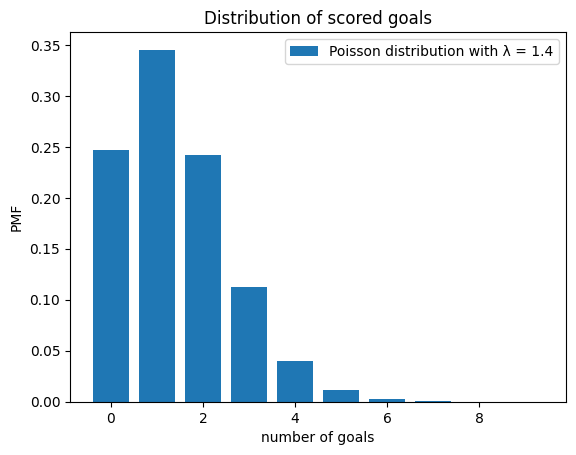

In [20]:
import matplotlib.pyplot as plt

pmf_goals.bar(label = 'Poisson distribution with λ = 1.4')
plt.xlabel('number of goals')
plt.ylabel('PMF')
plt.title('Distribution of scored goals')
plt.legend()
plt.show()

## Gamma Distribution